In [1]:
import glob

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
DONOR_ID_PATHS = glob.glob('/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/vireo_out/*/donor_ids.tsv')

In [3]:
DONOR_ID_PATHS

# Note SRR26424568 missing because not in the study and only one donor

['/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/vireo_out/SRR26424584/donor_ids.tsv',
 '/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/vireo_out/SRR26424563/donor_ids.tsv',
 '/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/vireo_out/SRR26424573/donor_ids.tsv',
 '/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/vireo_out/SRR26424577/donor_ids.tsv',
 '/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/vireo_out/SRR26424566/donor_ids.tsv',
 '/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/vireo_out/SRR26424562/donor_ids.tsv',
 '/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/vireo_out/SRR26424574/donor_ids.tsv',
 '/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/vireo_out/SRR26424589/donor_ids.tsv',
 '/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/vireo_out/SRR26424579/donor_ids.tsv',
 '/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/vireo_out/SRR26424583/donor_ids.tsv',
 '/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/vireo_out/SRR26

In [4]:
donor_id_path_list = []

for donor_id_path in DONOR_ID_PATHS:
    temp_df = None
    temp_df = pd.read_table(donor_id_path, sep='\t')
    temp_df['library'] = donor_id_path.split('/')[-2]
    donor_id_path_list.append(temp_df)

donor_id_df = pd.concat(donor_id_path_list, axis=0)

In [5]:
donor_id_df['donor_id'].value_counts()

donor_id
5401-35_NOW1_205061460074_R08C01     78407
unassigned                           60493
doublet                              51910
1323-4_NOW26_205061460074_R11C02     35367
3577-3_NOW28_205061460121_R09C01     35295
60C2_NOW29_205061460121_R11C02       32896
28126_NOW4_205061460121_R03C02       32166
WTC11_NOW6_205061460074_R05C02       10468
20961B_NOW9_205061460121_R11C01       7838
2909_NOW12_205061460121_R07C01        6603
7215-32_NOW11_205061460121_R05C01       12
Name: count, dtype: int64

In [48]:
(donor_id_df['donor_id'].value_counts() / donor_id_df.shape[0])*100

donor_id
5401-35_NOW1_205061460074_R08C01     22.309257
unassigned                           17.212161
doublet                              14.770027
1323-4_NOW26_205061460074_R11C02     10.063024
3577-3_NOW28_205061460121_R09C01     10.042537
60C2_NOW29_205061460121_R11C02        9.359947
28126_NOW4_205061460121_R03C02        9.152239
WTC11_NOW6_205061460074_R05C02        2.978475
20961B_NOW9_205061460121_R11C01       2.230157
2909_NOW12_205061460121_R07C01        1.878761
7215-32_NOW11_205061460121_R05C01     0.003414
Name: count, dtype: float64

In [7]:
donor_id_df['assigned'] = donor_id_df['donor_id'].apply(lambda x: False if (x == 'unassigned' or x == 'doublet') else True)

In [8]:
donor_id_df['assigned'].sum() / donor_id_df['assigned'].shape[0]

0.6801781166863468

In [9]:
donor_id_df['assigned'].sum()

239052

(0.0, 50000.0)

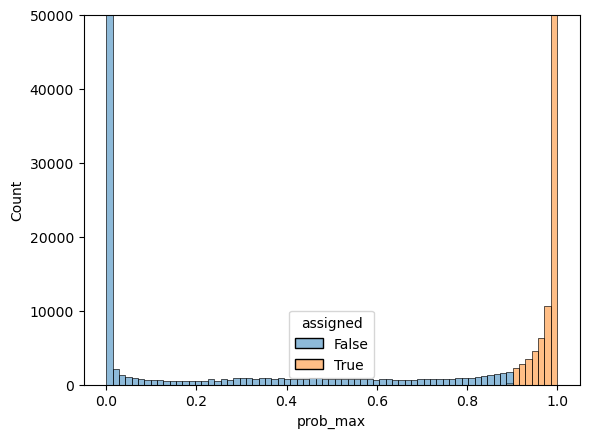

In [10]:
sns.histplot(data=donor_id_df, x='prob_max', hue='assigned')
plt.ylim(0,50000)

(0.0, 10000.0)

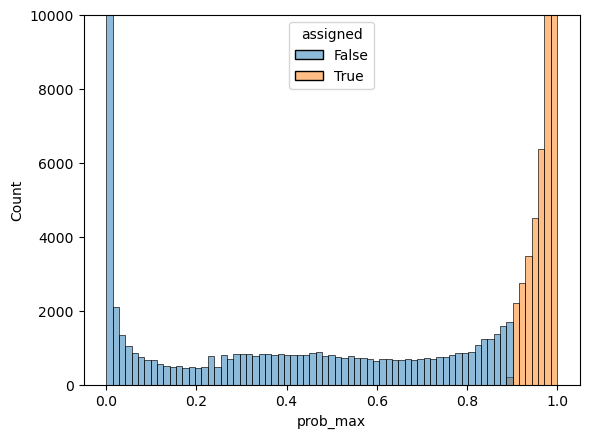

In [11]:
sns.histplot(data=donor_id_df, x='prob_max', hue='assigned')
plt.ylim(0,10000)

In [12]:
donor_id_df[(donor_id_df['prob_max'] > 0.9) & (donor_id_df['assigned'] == False)]

,cell,donor_id,prob_max,prob_doublet,n_vars,best_singlet,best_doublet,doublet_logLikRatio,library,assigned
384,ACTGTCCCAAGGGTCA,unassigned,0.976,0.01210,6,60C2_NOW29_205061460121_R11C02,"28126_NOW4_205061460121_R03C02,60C2_NOW29_2050...",-1.138,SRR26424586,False
1321,CACAGGCCAGTAGAGC,unassigned,0.976,0.00957,9,WTC11_NOW6_205061460074_R05C02,"5401-35_NOW1_205061460074_R08C01,WTC11_NOW6_20...",-1.372,SRR26424586,False
2293,CTACCCAGTACAGTTC,unassigned,0.926,0.01800,8,60C2_NOW29_205061460121_R11C02,"5401-35_NOW1_205061460074_R08C01,60C2_NOW29_20...",-0.686,SRR26424586,False
3377,GGAATGGTCCTAGCGG,unassigned,0.945,0.01830,9,5401-35_NOW1_205061460074_R08C01,"5401-35_NOW1_205061460074_R08C01,60C2_NOW29_20...",-0.689,SRR26424586,False


In [13]:
# Calculate the total count per library
total_counts = donor_id_df.groupby('library')['assigned'].count()

# Calculate the count of True values per library
true_counts = donor_id_df[donor_id_df['assigned'] == True].groupby('library')['assigned'].count()

# Calculate percentage of True values per library
percentage_true = (true_counts / total_counts) * 100

# Merge both the count and percentage into a new DataFrame
result = pd.DataFrame({
    'true_count': true_counts,
    'percentage_true': percentage_true
})

# Display the result
result.sort_values(by='percentage_true', ascending=False)

,true_count,percentage_true
library,,
SRR26424566,7599,91.964178
SRR26424572,7538,84.459384
SRR26424571,8016,84.183995
SRR26424570,8006,84.105473
SRR26424569,8060,83.975828
SRR26424567,21107,83.721391
SRR26424580,9136,80.486301
SRR26424579,9213,80.245623
SRR26424578,9038,79.798693


In [14]:
# donor_id_df.to_csv('/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/anndata_objs/minMAF_0pt1_minCount_10.csv')

# 0.7064872032223362 total assigned percentage

# 254151 total assigned cells

# 	true_count	percentage_true
# library		
# SRR26424562	14359	60.205451
# SRR26424563	14935	43.468770
# SRR26424564	16517	62.112665
# SRR26424585	1196	20.240311
# SRR26424586	739	13.480482
# SRR26424587	928	15.857826
# SRR26424588	9874	63.781409
# SRR26424589	8007	75.063279
# SRR26424590	5923	66.692940

# donor_ctx_libs = donor_id_df_old[(donor_id_df_old['library'].isin(['SRR26424585', 'SRR26424586', 'SRR26424587',
#                                                                    'SRR26424588', 'SRR26424589', 'SRR26424590',
#                                      'SRR26424562', 'SRR26424563', 'SRR26424564']))]

# donor_ctx_libs[donor_ctx_libs['assigned'] == True].shape[0] / donor_ctx_libs.shape[0]

# 0.5287586086144508 <- percentage assigned %%

In [15]:
# SRR26424566	7618	92.194118
# SRR26424565	7630	92.105263
# SRR26424567	22055	87.481655
# SRR26424572	7775	87.114846
# SRR26424571	8211	86.231884
# SRR26424569	8255	86.007502
# SRR26424570	8166	85.786322
# SRR26424580	9211	81.147036
# SRR26424579	9267	80.715966
# SRR26424577	9360	80.102696
# SRR26424574	9699	79.820591
# SRR26424578	9028	79.710401
# SRR26424573	9813	79.060587
# SRR26424575	9817	78.902106
# SRR26424576	9791	78.321734
# SRR26424581	8997	76.078133
# SRR26424584	8926	76.037141
# SRR26424583	9057	75.393324
# SRR26424589	8007	75.063279
# SRR26424582	8997	72.451280
# SRR26424590	5923	66.692940
# SRR26424588	9874	63.781409
# SRR26424564	16517	62.112665
# SRR26424562	14359	60.205451
# SRR26424563	14935	43.468770
# SRR26424585	1196	20.240311
# SRR26424587	928	15.857826
# SRR26424586	739	13.480482


In [16]:
## minMAF 0.1 and minCount 20

# donor_ctx_libs = donor_id_df[(donor_id_df['library'].isin(['SRR26424585', 'SRR26424586', 'SRR26424587', 'SRR26424588', 'SRR26424589', 'SRR26424590',
#                                      'SRR26424562', 'SRR26424563', 'SRR26424564']))]

# donor_ctx_libs[donor_ctx_libs['assigned'] == True].shape[0] / donor_ctx_libs.shape[0]

# 0.5253297537060815 <- 52% assigned overall for the important libraries

# SRR26424566	7606	92.048893
# SRR26424567	22058	87.493554
# SRR26424572	7714	86.431373
# SRR26424571	8135	85.433732
# SRR26424569	8161	85.028131
# SRR26424570	8084	84.924887
# SRR26424580	8982	79.129592
# SRR26424579	9022	78.582005
# SRR26424578	8817	77.847431
# SRR26424577	9081	77.715019
# SRR26424574	9440	77.689079
# SRR26424573	9558	77.006123
# SRR26424575	9542	76.691850
# SRR26424576	9539	76.305896
# SRR26424589	7958	74.603919
# SRR26424584	8672	73.873413
# SRR26424581	8722	73.752748
# SRR26424583	8784	73.120786
# SRR26424582	8697	70.035432
# SRR26424590	5882	66.231280
# SRR26424588	9792	63.251728
# SRR26424564	16418	61.740373
# SRR26424562	14227	59.651992
# SRR26424563	14962	43.547354
# SRR26424585	1155	19.546455
# SRR26424587	884	15.105947
# SRR26424586	730	13.316308

# donor_id_df.to_csv('/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/anndata_objs/minMAF_0pt1_minCount_20.csv')

In [17]:
# ## minMAF 0 and minCount 10 ##

# true_count	percentage_true
# library		
# SRR26424566	7599	91.964178
# SRR26424572	7538	84.459384
# SRR26424571	8016	84.183995
# SRR26424570	8006	84.105473
# SRR26424569	8060	83.975828
# SRR26424567	21107	83.721391
# SRR26424580	9136	80.486301
# SRR26424579	9213	80.245623
# SRR26424578	9038	79.798693
# SRR26424577	9324	79.794608
# SRR26424574	9616	79.137520
# SRR26424573	9784	78.826942
# SRR26424575	9788	78.669024
# SRR26424576	9786	78.281737
# SRR26424584	8992	76.599370
# SRR26424581	9001	76.111957
# SRR26424583	9117	75.892783
# SRR26424582	9290	74.810759
# SRR26424589	7676	71.960251
# SRR26424590	5654	63.664002
# SRR26424588	8636	55.784510
# SRR26424564	14271	53.666516
# SRR26424562	12694	53.224319
# SRR26424563	12844	37.382851
# SRR26424585	1792	30.326620
# SRR26424587	1620	27.682843
# SRR26424586	1454	26.523167

In [18]:
# donor_ctx_libs = donor_id_df[(donor_id_df['library'].isin(['SRR26424585', 'SRR26424586', 'SRR26424587', 'SRR26424588',
#                                                            'SRR26424589', 'SRR26424590', 'SRR26424562', 'SRR26424563', 
#                                                            'SRR26424564']))]

# donor_ctx_libs[donor_ctx_libs['assigned'] == True].shape[0] / donor_ctx_libs.shape[0]

# 0.4861751488268939 <- 48% assigned overall for the important libraries

# 	true_count	percentage_true
# library		
# SRR26424585	1792	30.326620
# SRR26424586	1454	26.523167
# SRR26424587	1620	27.682843
# SRR26424588	8636	55.784510
# SRR26424589	7676	71.960251
# SRR26424590	5654	63.664002
# SRR26424562	12694	53.224319
# SRR26424563	12844	37.382851
# SRR26424564	14271	53.666516

# true_count         66641.00000
# percentage_true      420.21508
# dtype: float64

# donor_id_df.to_csv('/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/anndata_objs/minMAF_0pt0_minCount_10.csv')

In [19]:
minMAF01_minCount10 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/anndata_objs/minMAF_0pt1_minCount_10.csv', index_col=0)
minMAF01_minCount20 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/anndata_objs/minMAF_0pt1_minCount_20.csv', index_col=0)
minMAF00_minCount10 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/anndata_objs/minMAF_0pt0_minCount_10.csv', index_col=0)

In [20]:
minMAF01_minCount10_libs = minMAF01_minCount10[(minMAF01_minCount10['library'].isin(['SRR26424585', 'SRR26424586', 'SRR26424587', 
                                                                                     'SRR26424588', 'SRR26424589', 'SRR26424590',
                                                                                     'SRR26424562', 'SRR26424563', 'SRR26424564']))]

minMAF01_minCount20_libs = minMAF01_minCount20[(minMAF01_minCount20['library'].isin(['SRR26424585', 'SRR26424586', 'SRR26424587', 
                                                                                     'SRR26424588', 'SRR26424589', 'SRR26424590', 
                                                                                     'SRR26424562', 'SRR26424563', 'SRR26424564']))]

minMAF00_minCount10_libs = minMAF00_minCount10[(minMAF00_minCount10['library'].isin(['SRR26424585', 'SRR26424586', 'SRR26424587', 
                                                                                     'SRR26424588', 'SRR26424589', 'SRR26424590', 
                                                                                     'SRR26424562', 'SRR26424563', 'SRR26424564']))]

In [21]:
minMAF01_minCount10_libs[minMAF01_minCount10_libs['assigned'] == True].shape[0] / minMAF01_minCount10_libs.shape[0]

0.5287586086144508

In [22]:
minMAF01_minCount20_libs[minMAF01_minCount20_libs['assigned'] == True].shape[0] / minMAF01_minCount20_libs.shape[0]

0.5253297537060815

In [23]:
minMAF00_minCount10_libs[minMAF00_minCount10_libs['assigned'] == True].shape[0] / minMAF00_minCount10_libs.shape[0]

0.4861751488268939

In [24]:
minMAF01_minCount10_libs_red = minMAF01_minCount10[(minMAF01_minCount10['library'].isin(['SRR26424585', 'SRR26424586', 'SRR26424587', 
                                                                                     'SRR26424588', 
                                                                                     'SRR26424562', 'SRR26424563', 'SRR26424564']))]

minMAF01_minCount20_libs_red = minMAF01_minCount20[(minMAF01_minCount20['library'].isin(['SRR26424585', 'SRR26424586', 'SRR26424587', 
                                                                                     'SRR26424588', 
                                                                                     'SRR26424562', 'SRR26424563', 'SRR26424564']))]

minMAF00_minCount10_libs_red = minMAF00_minCount10[(minMAF00_minCount10['library'].isin(['SRR26424585', 'SRR26424586', 'SRR26424587', 
                                                                                     'SRR26424588', 
                                                                                     'SRR26424562', 'SRR26424563', 'SRR26424564']))]

In [25]:
minMAF01_minCount10_libs_red[minMAF01_minCount10_libs_red['assigned'] == True].shape[0] / minMAF01_minCount10_libs_red.shape[0]

0.49817909533371907

In [26]:
minMAF01_minCount20_libs_red[minMAF01_minCount20_libs_red['assigned'] == True].shape[0] / minMAF01_minCount20_libs_red.shape[0]

0.494945713216024

In [27]:
minMAF00_minCount10_libs_red[minMAF00_minCount10_libs_red['assigned'] == True].shape[0] / minMAF00_minCount10_libs_red.shape[0]

0.45361798441169465

In [28]:
(minMAF01_minCount10_libs_red['prob_max'] > 0.9).sum()

60075

In [29]:
minMAF01_minCount10_libs_red['assigned'].sum()

58548

In [37]:
minMAF01_minCount10[(minMAF01_minCount10['library'].isin(['SRR26424585', 'SRR26424586', 'SRR26424587', 'SRR26424588']))][['library', 'donor_id']].value_counts().sort_index()

library      donor_id                        
SRR26424585  28126_NOW4_205061460121_R03C02       286
             5401-35_NOW1_205061460074_R08C01     242
             60C2_NOW29_205061460121_R11C02       429
             WTC11_NOW6_205061460074_R05C02       239
             doublet                              127
             unassigned                          4586
SRR26424586  28126_NOW4_205061460121_R03C02       195
             3577-3_NOW28_205061460121_R09C01     138
             5401-35_NOW1_205061460074_R08C01     187
             60C2_NOW29_205061460121_R11C02       219
             doublet                               59
             unassigned                          4684
SRR26424587  28126_NOW4_205061460121_R03C02       223
             5401-35_NOW1_205061460074_R08C01     205
             60C2_NOW29_205061460121_R11C02       295
             WTC11_NOW6_205061460074_R05C02       205
             doublet                              123
             unassigned             

<Axes: xlabel='prob_max', ylabel='Count'>

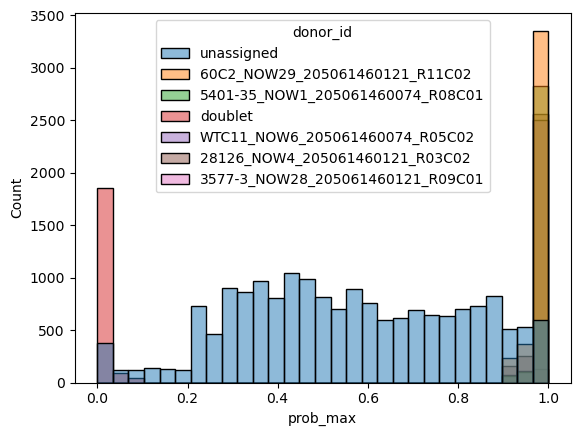

In [42]:
sns.histplot(data=minMAF01_minCount10[(minMAF01_minCount10['library'].isin(['SRR26424585', 'SRR26424586', 'SRR26424587', 'SRR26424588']))],
             x='prob_max', hue='donor_id')

In [40]:
subset = minMAF01_minCount10[
    minMAF01_minCount10['library'].isin([
        'SRR26424585', 'SRR26424586', 
        'SRR26424587', 'SRR26424588'
    ])
]

counts = (
    subset[['library', 'donor_id']]
    .value_counts()
    .rename('count')
    .reset_index()
)

# Calculate percentage within each library
counts['percentage'] = (
    counts['count'] /
    counts.groupby('library')['count'].transform('sum')
) * 100

counts = counts.sort_values(['library', 'donor_id'])

counts

,library,donor_id,count,percentage
11,SRR26424585,28126_NOW4_205061460121_R03C02,286,4.840074
12,SRR26424585,5401-35_NOW1_205061460074_R08C01,242,4.095448
9,SRR26424585,60C2_NOW29_205061460121_R11C02,429,7.260112
13,SRR26424585,WTC11_NOW6_205061460074_R05C02,239,4.044678
21,SRR26424585,doublet,127,2.149264
2,SRR26424585,unassigned,4586,77.610425
18,SRR26424586,28126_NOW4_205061460121_R03C02,195,3.557096
20,SRR26424586,3577-3_NOW28_205061460121_R09C01,138,2.517329
19,SRR26424586,5401-35_NOW1_205061460074_R08C01,187,3.411164
15,SRR26424586,60C2_NOW29_205061460121_R11C02,219,3.994892


In [38]:
minMAF01_minCount10[(minMAF01_minCount10['library'].isin(['SRR26424589', 'SRR26424590']))][['library', 'donor_id']].value_counts().sort_index()

library      donor_id                         
SRR26424589  28126_NOW4_205061460121_R03C02       1446
             3577-3_NOW28_205061460121_R09C01     5325
             5401-35_NOW1_205061460074_R08C01     1194
             7215-32_NOW11_205061460121_R05C01      42
             doublet                               297
             unassigned                           2363
SRR26424590  28126_NOW4_205061460121_R03C02        949
             3577-3_NOW28_205061460121_R09C01     3212
             5401-35_NOW1_205061460074_R08C01     1762
             doublet                               700
             unassigned                           2258
Name: count, dtype: int64

In [47]:
minMAF01_minCount10.groupby('library')['assigned'].mean().mul(100)

library
SRR26424562    60.205451
SRR26424563    43.468770
SRR26424564    62.112665
SRR26424565    92.105263
SRR26424566    92.194118
SRR26424567    87.481655
SRR26424569    86.007502
SRR26424570    85.786322
SRR26424571    86.231884
SRR26424572    87.114846
SRR26424573    79.060587
SRR26424574    79.820591
SRR26424575    78.902106
SRR26424576    78.321734
SRR26424577    80.102696
SRR26424578    79.710401
SRR26424579    80.715966
SRR26424580    81.147036
SRR26424581    76.078133
SRR26424582    72.451280
SRR26424583    75.393324
SRR26424584    76.037141
SRR26424585    20.240311
SRR26424586    13.480482
SRR26424587    15.857826
SRR26424588    63.781409
SRR26424589    75.063279
SRR26424590    66.692940
Name: assigned, dtype: float64

In [56]:
donors = pd.read_table('/mnt/sda/scz_meta_analysis/shin_nowakowski_cellstemcell_2025/genotypes/gtc2vcf/vcfs/donors_relatedness.genome', delim_whitespace=True)

/tmp/ipykernel_16254/274259903.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  donors = pd.read_table('/mnt/sda/scz_meta_analysis/shin_nowakowski_cellstemcell_2025/genotypes/gtc2vcf/vcfs/donors_relatedness.genome', delim_whitespace=True)


In [57]:
donors[['FID1', 'FID2', 'PI_HAT']]

,FID1,FID2,PI_HAT
0,5401-35_NOW1_205061460074_R08C01,WTC11_NOW6_205061460074_R05C02,0.4139
1,5401-35_NOW1_205061460074_R08C01,1323-4_NOW26_205061460074_R11C02,0.4121
2,5401-35_NOW1_205061460074_R08C01,7215-32_NOW11_205061460121_R05C01,0.4139
3,5401-35_NOW1_205061460074_R08C01,3577-3_NOW28_205061460121_R09C01,0.4119
4,5401-35_NOW1_205061460074_R08C01,60C2_NOW29_205061460121_R11C02,0.4119
5,5401-35_NOW1_205061460074_R08C01,20961B_NOW9_205061460121_R11C01,0.4127
6,5401-35_NOW1_205061460074_R08C01,2909_NOW12_205061460121_R07C01,0.4138
7,5401-35_NOW1_205061460074_R08C01,28126_NOW4_205061460121_R03C02,0.4147
8,WTC11_NOW6_205061460074_R05C02,1323-4_NOW26_205061460074_R11C02,0.3771
9,WTC11_NOW6_205061460074_R05C02,7215-32_NOW11_205061460121_R05C01,0.3792
